# 🧠 NeuroSense AI - ResNet18 MRI Brain Classifier Training
This Jupyter notebook downloads the OASIS Alzheimer's Multi-Class Dataset using `kagglehub`, trains a PyTorch `ResNet18` fine-tuned image classifier with real-time progress bars (`tqdm`), time estimation, dataset visualization, and exports the final `.pth` weights for the NeuroSense AI backend (`backend/app/models/alzheimer_model.pth`).

In [3]:
# Step 1: Install Dependencies
!pip install -q torch torchvision kagglehub matplotlib seaborn scikit-learn pillow tqdm

In [5]:
# Step 2: Download OASIS Dataset via kagglehub & Create Local Shortcut
import kagglehub
import os
import shutil

# Download latest version of OASIS Alzheimer's multi-class dataset
dataset_path = kagglehub.dataset_download("shreyanmohanty/oasis-alzheimers-detection-multi-class-dataset")
print("📁 Dataset Cache Path:", dataset_path)

# Create a visible symlink/folder in Colab Workspace (/content/dataset)
colab_dataset_dir = "/content/dataset"
if os.path.exists(colab_dataset_dir):
    if os.path.islink(colab_dataset_dir):
        os.unlink(colab_dataset_dir)
    else:
        shutil.rmtree(colab_dataset_dir)
os.symlink(dataset_path, colab_dataset_dir)
print("✅ Created workspace link at: /content/dataset (Visible in Colab Files Panel)")

# Display dataset directory structure and counts
print("📊 Dataset Content Overview:")
for root, dirs, files in os.walk(dataset_path):
    rel_path = os.path.relpath(root, dataset_path)
    if rel_path == ".":
        print(f"Root Folder -> Subfolders: {dirs}")
    elif len(dirs) > 0 or len(files) > 0:
        print(f"  📁 {rel_path} -> Images count: {len(files)}")

Using Colab cache for faster access to the 'oasis-alzheimers-detection-multi-class-dataset' dataset.
📁 Dataset Cache Path: /kaggle/input/oasis-alzheimers-detection-multi-class-dataset
✅ Created workspace link at: /content/dataset (Visible in Colab Files Panel)
📊 Dataset Content Overview:
Root Folder -> Subfolders: ['test', 'train']
  📁 test -> Images count: 1
  📁 test/ModerateDemented -> Images count: 168
  📁 test/NonDemented -> Images count: 40852
  📁 test/VeryMildDemented -> Images count: 4505
  📁 test/MildDemented -> Images count: 659
  📁 train -> Images count: 1
  📁 train/ModerateDemented -> Images count: 1039
  📁 train/NonDemented -> Images count: 22705
  📁 train/VeryMildDemented -> Images count: 18124
  📁 train/MildDemented -> Images count: 13575


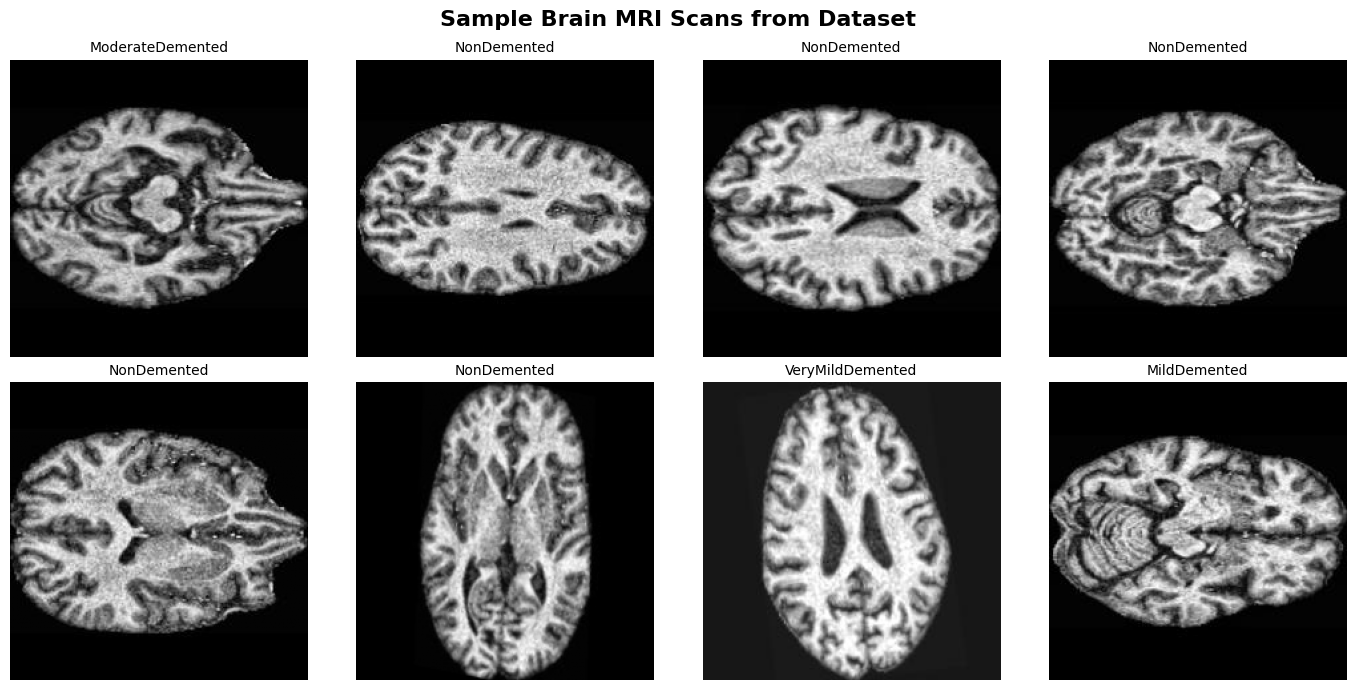

In [6]:
# Step 3: Visualize Sample MRI Images from Dataset
import matplotlib.pyplot as plt
from PIL import Image
import glob

sample_images = glob.glob(os.path.join(dataset_path, "**/*.jpg"), recursive=True) + \
                glob.glob(os.path.join(dataset_path, "**/*.png"), recursive=True)

if sample_images:
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    fig.suptitle("Sample Brain MRI Scans from Dataset", fontsize=16, fontweight='bold')
    for idx, ax in enumerate(axes.flat):
        if idx < len(sample_images):
            img_path = sample_images[idx * (len(sample_images) // 8)]
            img = Image.open(img_path)
            label = os.path.basename(os.path.dirname(img_path))
            ax.imshow(img, cmap='gray')
            ax.set_title(label, fontsize=10)
            ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No sample images found to display.")

In [7]:
# Step 4: PyTorch Data Setup & Augmentation
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using Compute Device: {device}")
if torch.cuda.is_available():
    print(f"🎮 GPU Model: {torch.cuda.get_device_name(0)}")

IMAGE_SIZE = 224
BATCH_SIZE = 32

# Image Transformations
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Locate Data Split Directories
train_dir = os.path.join(dataset_path, 'train') if os.path.exists(os.path.join(dataset_path, 'train')) else dataset_path
val_dir = os.path.join(dataset_path, 'test') if os.path.exists(os.path.join(dataset_path, 'test')) else dataset_path

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class_names = train_dataset.classes
print(f"✅ Loaded Dataset with {len(train_dataset)} Train & {len(val_dataset)} Validation images.")
print(f"🏷️ Classification Classes ({len(class_names)}): {class_names}")

🚀 Using Compute Device: cuda:0
🎮 GPU Model: Tesla T4
✅ Loaded Dataset with 55443 Train & 46184 Validation images.
🏷️ Classification Classes (4): ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


In [8]:
# Step 5: Model Building (ResNet18 Fine-tuning)
def build_mri_model(num_classes=4):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # Freeze baseline layers
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze high-level feature extractor layer4
    for param in model.layer4.parameters():
        param.requires_grad = True

    # Replace final classification head
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, num_classes)
    )
    return model

model = build_mri_model(num_classes=len(class_names)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
print("✅ ResNet18 MRI Architecture Initialized!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 200MB/s]


✅ ResNet18 MRI Architecture Initialized!


In [9]:
# Step 6: Enhanced Training Loop with tqdm Progress Bars & Time Estimation
import time
from tqdm.notebook import tqdm

EPOCHS = 10
best_acc = 0.0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("⚡ Starting Model Training with Real-Time Progress Tracking...")
start_total_time = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()
    print(f"\n--------------------------------------------------")
    print(f"🔄 Epoch {epoch+1:02d}/{EPOCHS:02d}")
    print(f"--------------------------------------------------")

    # --- Training Phase ---
    model.train()
    running_loss, running_corrects = 0.0, 0

    train_pbar = tqdm(train_loader, desc=f"Train Epoch {epoch+1}/{EPOCHS}", unit="batch", leave=False)
    for inputs, labels in train_pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

        # Update progress bar description with current batch loss
        train_pbar.set_postfix(batch_loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = (running_corrects.double() / len(train_dataset)).item()

    # --- Validation Phase ---
    model.eval()
    val_loss, val_corrects = 0.0, 0

    val_pbar = tqdm(val_loader, desc=f"Val Epoch {epoch+1}/{EPOCHS}", unit="batch", leave=False)
    with torch.no_grad():
        for inputs, labels in val_pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            val_loss += loss.item() * inputs.size(0)
            val_corrects += torch.sum(preds == labels.data)
            val_pbar.set_postfix(val_batch_loss=f"{loss.item():.4f}")

    val_epoch_loss = val_loss / len(val_dataset)
    val_epoch_acc = (val_corrects.double() / len(val_dataset)).item()

    # Store metrics history
    history['train_loss'].append(epoch_loss)
    history['train_acc'].append(epoch_acc)
    history['val_loss'].append(val_epoch_loss)
    history['val_acc'].append(val_epoch_acc)

    epoch_duration = time.time() - epoch_start
    elapsed_total = time.time() - start_total_time
    avg_epoch_time = elapsed_total / (epoch + 1)
    rem_epochs = EPOCHS - (epoch + 1)
    est_remaining = rem_epochs * avg_epoch_time

    print(f"📊 Results: Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc*100:.2f}%")
    print(f"           Val Loss:   {val_epoch_loss:.4f} | Val Acc:   {val_epoch_acc*100:.2f}%")
    print(f"⏱️ Epoch Time: {epoch_duration:.1f}s | Elapsed: {elapsed_total/60:.1f}m | Est. Remaining: {est_remaining/60:.1f}m")

    # Save Model Weights if Acc Improves
    if val_epoch_acc > best_acc:
        best_acc = val_epoch_acc
        torch.save(model.state_dict(), 'alzheimer_model.pth')
        print(f"🏆 Saved New Best Weights! (Best Val Accuracy: {best_acc*100:.2f}%)")

print(f"\n🎉 Training Complete in {(time.time() - start_total_time)/60:.2f} minutes!")
print(f"🌟 Best Validation Accuracy Achieved: {best_acc*100:.2f}%")

⚡ Starting Model Training with Real-Time Progress Tracking...

--------------------------------------------------
🔄 Epoch 01/10
--------------------------------------------------


Train Epoch 1/10:   0%|          | 0/1733 [00:00<?, ?batch/s]

Val Epoch 1/10:   0%|          | 0/1444 [00:00<?, ?batch/s]

📊 Results: Train Loss: 0.5903 | Train Acc: 73.56%
           Val Loss:   0.7109 | Val Acc:   70.94%
⏱️ Epoch Time: 410.9s | Elapsed: 6.8m | Est. Remaining: 61.6m
🏆 Saved New Best Weights! (Best Val Accuracy: 70.94%)

--------------------------------------------------
🔄 Epoch 02/10
--------------------------------------------------


Train Epoch 2/10:   0%|          | 0/1733 [00:00<?, ?batch/s]

...

Val Epoch 9/10:   0%|          | 0/1444 [00:00<?, ?batch/s]

📊 Results: Train Loss: 0.1396 | Train Acc: 94.63%
           Val Loss:   1.1959 | Val Acc:   75.12%
⏱️ Epoch Time: 296.3s | Elapsed: 47.2m | Est. Remaining: 5.2m

--------------------------------------------------
🔄 Epoch 10/10
--------------------------------------------------


Train Epoch 10/10:   0%|          | 0/1733 [00:00<?, ?batch/s]

Val Epoch 10/10:   0%|          | 0/1444 [00:00<?, ?batch/s]

📊 Results: Train Loss: 0.1194 | Train Acc: 95.45%
           Val Loss:   1.3864 | Val Acc:   72.27%
⏱️ Epoch Time: 299.0s | Elapsed: 52.2m | Est. Remaining: 0.0m

🎉 Training Complete in 52.19 minutes!
🌟 Best Validation Accuracy Achieved: 75.94%


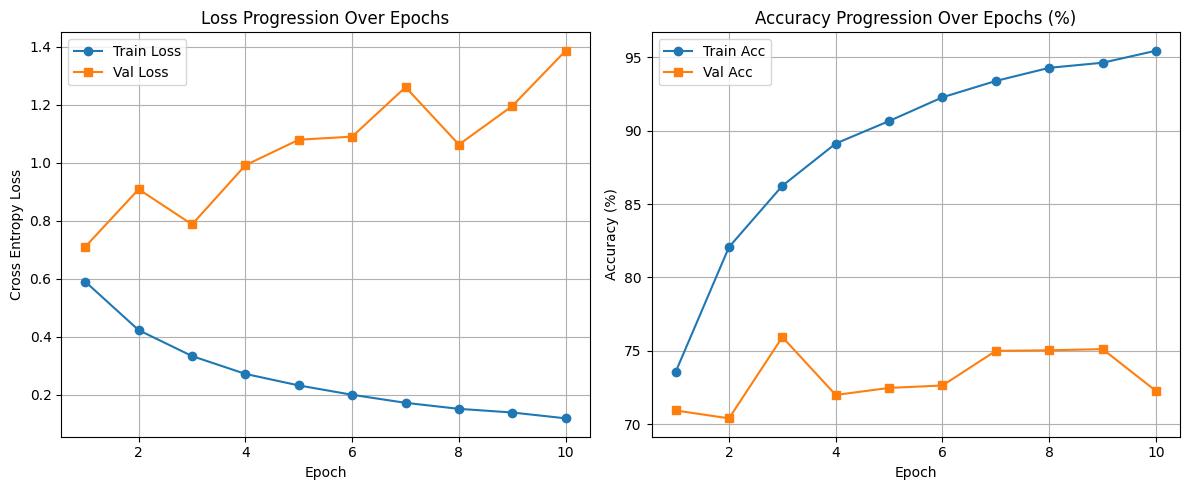

In [10]:
# Step 7: Plot Training Metrics & Accuracy Curves
plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), history['train_loss'], label='Train Loss', marker='o')
plt.plot(range(1, EPOCHS + 1), history['val_loss'], label='Val Loss', marker='s')
plt.title('Loss Progression Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.legend()
plt.grid(True)

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), [acc * 100 for acc in history['train_acc']], label='Train Acc', marker='o')
plt.plot(range(1, EPOCHS + 1), [acc * 100 for acc in history['val_acc']], label='Val Acc', marker='s')
plt.title('Accuracy Progression Over Epochs (%)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [11]:
# Step 8: Download Trained Model Weights for NeuroSense AI Backend
from google.colab import files
print("📥 Downloading alzheimer_model.pth file to your computer...")
files.download('alzheimer_model.pth')

📥 Downloading alzheimer_model.pth file to your computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>